### Covered Call Strategy

This is the most popular strategy, and it works by buying the underlying stock as usual and simultaneously write a call option on those same shares.

This approach generates income and reduces the risk of being long on the stock alone.
> Use this strategy when you have a short-term position in the stock and a neutral opinion on its direction.

Call Option:
- Gives the option holder the right to buy the underlying asset.

Put Option:
- Gives the holder the right to sell the underlying asset.

**The Strategy:**
We hold SPX (long the index) and sell an OTM call against it every month, and collect the premium upfront:
- If SPX stays below the strike at expiry, we keep the premium and repeat.
- If SPX rallies above the strike price we get capped - upside is limited to the strike plus premium collected.

The trade is essentially selling volatility. We profit when realised volatility is lower than implied volatility.

In [1]:
import os
import sys

In [2]:
sys.path.append(os.path.join(os.getcwd(), "../", "../"))

In [3]:
import matplotx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from datetime import datetime

In [5]:
from src.python.utils import load_file_chunks

In [6]:
plt.style.use(matplotx.styles.dracula)

In [7]:
DATA_PATH = os.path.join(os.getcwd(), "../", "../", "data")
OPTIONS_DATA_PATH = os.path.join(DATA_PATH, "spx_options_processed.csv")

In [8]:
start_date = datetime(2015, 1, 2)
end_date = datetime(2016, 1, 2)

In [9]:
df = load_file_chunks(OPTIONS_DATA_PATH, start_date, end_date)

In [16]:
candidates = df[
    (df['date'] == start_date) &
    (df['cp_flag'] == 'C') &
    (df['dte'].between(28, 32)) &
    (df['delta'].between(0.23, 0.27))
]

In [ ]:
print(candidates)

In [19]:
target_delta = 0.25
chosen = candidates.iloc[(candidates['delta'] - target_delta).abs().argsort()[:1]]
print(chosen[['date', 'exdate', 'strike_price', 'delta', 'dte', 'mid', 'impl_volatility', 'optionid']])

              date      exdate  strike_price     delta  dte    mid  \
1934482 2015-01-02  2015-01-30        2100.0  0.262154   28  10.45   

         impl_volatility   optionid  
1934482         0.117277  104648618  


In [20]:
option_id = 104648618

In [21]:
end_date_strat = datetime(2015, 1, 30)

In [26]:
trade_underlying = df[
    (df['date'] >= start_date) &
    (df['date'] <= end_date_strat)
][['date', 'spot', 'spx_return']].drop_duplicates(subset='date').sort_values('date')

In [29]:
trade_option = df[
    (df['optionid'] == 104648618) &
    (df['date'] >= start_date) &
    (df['date'] <= end_date_strat)
][['date', 'mid', 'delta', 'impl_volatility']]

In [30]:
print(trade_underlying)

              date     spot  spx_return
1932708 2015-01-02  2058.20   -0.000340
1936861 2015-01-05  2020.58   -0.018278
1941011 2015-01-06  2002.61   -0.008893
1945103 2015-01-07  2025.90    0.011630
1948967 2015-01-08  2062.14    0.017888
1953132 2015-01-09  2044.81   -0.008404
1957547 2015-01-12  2028.26   -0.008094
1961640 2015-01-13  2023.03   -0.002579
1965524 2015-01-14  2011.27   -0.005813
1969479 2015-01-15  1992.67   -0.009248
1973742 2015-01-16  2019.42    0.013424
1977819 2015-01-20  2022.55    0.001550
1981614 2015-01-21  2032.12    0.004732
1985676 2015-01-22  2063.15    0.015270
1989695 2015-01-23  2051.82   -0.005492
1993639 2015-01-26  2057.09    0.002568
1997491 2015-01-27  2029.55   -0.013388
2001494 2015-01-28  2002.16   -0.013496
2005584 2015-01-29  2021.25    0.009535
2009681 2015-01-30  1994.99   -0.012992


In [31]:
print(trade_option)

              date     mid     delta  impl_volatility
1934482 2015-01-02  10.450  0.262154         0.117277
1938654 2015-01-05   3.650  0.115347         0.124345
1942744 2015-01-06   2.250  0.075907         0.130281
1946665 2015-01-07   3.650  0.119917         0.123253
1950555 2015-01-08   9.000  0.256926         0.116584
1954875 2015-01-09   4.650  0.160197         0.113791
1958986 2015-01-12   2.675  0.101694         0.124327
1962936 2015-01-13   2.250  0.087722         0.128781
1966889 2015-01-14   2.225  0.080029         0.147439
1971011 2015-01-15   1.475  0.054099         0.161432
1975030 2015-01-16   2.725  0.096392         0.153983
1979019 2015-01-20   1.600  0.070468         0.154680
1982989 2015-01-21   1.400  0.070153         0.142567
1986826 2015-01-22   2.500  0.142376         0.113206


In [32]:
trade = trade_underlying.merge(trade_option, on='date', how='left')

In [33]:
trade['mid'] = trade['mid'].fillna(0)

In [34]:
print(trade[['date', 'spot', 'spx_return', 'mid']])

         date     spot  spx_return     mid
0  2015-01-02  2058.20   -0.000340  10.450
1  2015-01-05  2020.58   -0.018278   3.650
2  2015-01-06  2002.61   -0.008893   2.250
3  2015-01-07  2025.90    0.011630   3.650
4  2015-01-08  2062.14    0.017888   9.000
5  2015-01-09  2044.81   -0.008404   4.650
6  2015-01-12  2028.26   -0.008094   2.675
7  2015-01-13  2023.03   -0.002579   2.250
8  2015-01-14  2011.27   -0.005813   2.225
9  2015-01-15  1992.67   -0.009248   1.475
10 2015-01-16  2019.42    0.013424   2.725
11 2015-01-20  2022.55    0.001550   1.600
12 2015-01-21  2032.12    0.004732   1.400
13 2015-01-22  2063.15    0.015270   2.500
14 2015-01-23  2051.82   -0.005492   0.000
15 2015-01-26  2057.09    0.002568   0.000
16 2015-01-27  2029.55   -0.013388   0.000
17 2015-01-28  2002.16   -0.013496   0.000
18 2015-01-29  2021.25    0.009535   0.000
19 2015-01-30  1994.99   -0.012992   0.000


In [35]:
premium_received = chosen['mid'].values[0]
print(premium_received)

10.45


In [36]:
trade['option_pnl'] = premium_received - trade['mid']

In [37]:
trade['option_daily_pnl'] = trade['mid'].shift(1) - trade['mid']

In [ ]:
trade['option_daily_pnl'].iloc[0] = 0

In [39]:
trade['combined_daily_pnl'] = trade['spx_return'] * trade['spot'].iloc[0] + trade['option_daily_pnl']
trade['cumulative_pnl'] = trade['combined_daily_pnl'].cumsum()

In [42]:
print(trade[['date', 'spot', 'option_pnl', 'option_daily_pnl', 'combined_daily_pnl', 'cumulative_pnl']])

         date     spot  option_pnl  option_daily_pnl  combined_daily_pnl  \
0  2015-01-02  2058.20       0.000               NaN                 NaN   
1  2015-01-05  2020.58       6.800             6.800          -30.819780   
2  2015-01-06  2002.61       8.200             1.400          -16.903573   
3  2015-01-07  2025.90       6.800            -1.400           22.536866   
4  2015-01-08  2062.14       1.450            -5.350           31.467082   
5  2015-01-09  2044.81       5.800             4.350          -12.947113   
6  2015-01-12  2028.26       7.775             1.975          -14.684071   
7  2015-01-13  2023.03       8.200             0.425           -4.883098   
8  2015-01-14  2011.27       8.225             0.025          -11.939317   
9  2015-01-15  1992.67       8.975             0.750          -18.284234   
10 2015-01-16  2019.42       7.725            -1.250           26.379277   
11 2015-01-20  2022.55       8.850             1.125            4.315210   
12 2015-01-2

In [44]:
trade.loc[trade.index[0], 'option_daily_pnl'] = 0
trade.loc[trade.index[0], 'combined_daily_pnl'] = 0
trade['cumulative_pnl'] = trade['combined_daily_pnl'].cumsum()

In [45]:
trade['buy_and_hold'] = trade['spot'] - trade['spot'].iloc[0]

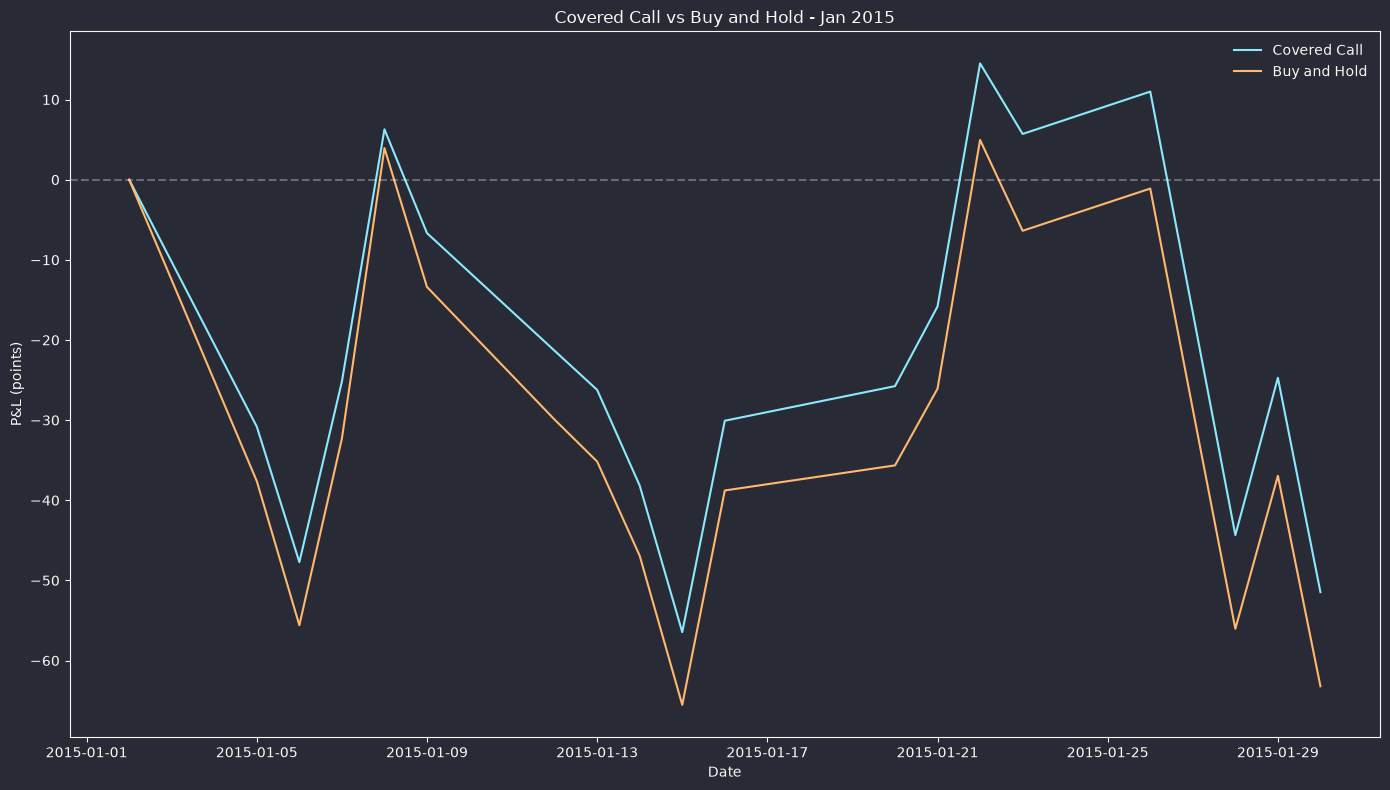

In [46]:
plt.figure(figsize=(14, 8))
plt.plot(trade['date'], trade['cumulative_pnl'], label='Covered Call')
plt.plot(trade['date'], trade['buy_and_hold'], label='Buy and Hold')
plt.axhline(y=0, color='white', linestyle='--', alpha=0.3)
plt.title('Covered Call vs Buy and Hold - Jan 2015')
plt.xlabel('Date')
plt.ylabel('P&L (points)')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
def select_option(date, df):
    candidates = df[
        (df['date'] == date) &
        (df['cp_flag'] == 'C') &
        (df['dte'].between(28, 32)) &
        (df['delta'].between(0.23, 0.27))
    ]

    target_delta = 0.25
    chosen = candidates.iloc[(candidates['delta'] - target_delta).abs().argsort()[:1]]
    return chosen

In [48]:
def get_trade_data(row, df):
    entry_date = row['date'].values[0]
    expiry_date = row['exdate'].values[0]
    option_id = row['optionid'].values[0]

    trade_underlying = df[
        (df['date'] >= entry_date) &
        (df['date'] <= expiry_date)
    ][['date', 'spot', 'spx_return']].drop_duplicates(subset='date').sort_values('date')

    trade_option = df[
        (df['optionid'] == option_id) &
        (df['date'] >= entry_date) &
        (df['date'] <= expiry_date)
    ][['date', 'mid', 'delta', 'impl_volatility']]

    trade = trade_underlying.merge(trade_option, on='date', how='left')
    trade['mid'] = trade['mid'].fillna(0)
    return trade

In [49]:
def compute_pnl(premium, df):
    df['option_pnl'] = premium - df['mid']
    df['option_daily_pnl'] = df['mid'].shift(1) - df['mid']
    df.loc[df.index[0], 'option_daily_pnl'] = 0
    df['combined_daily_pnl'] = df['spx_return'] * df['spot'].iloc[0] + df['option_daily_pnl']
    df.loc[df.index[0], 'combined_daily_pnl'] = 0
    df['cumulative_pnl'] = df['combined_daily_pnl'].cumsum()

    return df

In [50]:
chosen = select_option(start_date, df)
trade = get_trade_data(chosen, df)
premium = chosen['mid'].values[0]
result = compute_pnl(premium, trade)

In [51]:
print(result[['date', 'spot', 'mid', 'combined_daily_pnl', 'cumulative_pnl']])

         date     spot     mid  combined_daily_pnl  cumulative_pnl
0  2015-01-02  2058.20  10.450            0.000000        0.000000
1  2015-01-05  2020.58   3.650          -30.819780      -30.819780
2  2015-01-06  2002.61   2.250          -16.903573      -47.723352
3  2015-01-07  2025.90   3.650           22.536866      -25.186486
4  2015-01-08  2062.14   9.000           31.467082        6.280595
5  2015-01-09  2044.81   4.650          -12.947113       -6.666517
6  2015-01-12  2028.26   2.675          -14.684071      -21.350588
7  2015-01-13  2023.03   2.250           -4.883098      -26.233686
8  2015-01-14  2011.27   2.225          -11.939317      -38.173003
9  2015-01-15  1992.67   1.475          -18.284234      -56.457236
10 2015-01-16  2019.42   2.725           26.379277      -30.077959
11 2015-01-20  2022.55   1.600            4.315210      -25.762749
12 2015-01-21  2032.12   1.400            9.939402      -15.823347
13 2015-01-22  2063.15   2.500           30.328714       14.50

In [94]:
roll_dates = []
all_trades = []
chosen_options = []

In [95]:
trading_dates = sorted(df['date'].unique())

In [96]:
def snap_to_next_trading_date(date, trading_dates):
    future_dates = [d for d in trading_dates if d >= date]
    return future_dates[0] if future_dates else None

In [97]:
current_date = start_date

In [98]:
while True:
    if current_date is None or current_date >= end_date:
        break

    chosen = select_option(current_date, df)

    if chosen.empty:
        idx = trading_dates.index(current_date)
        current_date = trading_dates[idx + 1]
        continue

    trade = get_trade_data(chosen, df)
    premium = chosen['mid'].values[0]
    result = compute_pnl(premium, trade)

    roll_dates.append(current_date)
    all_trades.append(result)
    chosen_options.append(chosen)

    expiry = pd.Timestamp(chosen['exdate'].values[0])
    current_date = snap_to_next_trading_date(expiry, trading_dates)

In [99]:
len(all_trades)

13

In [100]:
full_results = pd.concat(all_trades).reset_index(drop=True)
print(full_results.shape)

(263, 10)


In [101]:
print(full_results[['date', 'spot', 'combined_daily_pnl', 'cumulative_pnl']].head(20))

         date     spot  combined_daily_pnl  cumulative_pnl
0  2015-01-02  2058.20            0.000000        0.000000
1  2015-01-05  2020.58          -30.819780      -30.819780
2  2015-01-06  2002.61          -16.903573      -47.723352
3  2015-01-07  2025.90           22.536866      -25.186486
4  2015-01-08  2062.14           31.467082        6.280595
5  2015-01-09  2044.81          -12.947113       -6.666517
6  2015-01-12  2028.26          -14.684071      -21.350588
7  2015-01-13  2023.03           -4.883098      -26.233686
8  2015-01-14  2011.27          -11.939317      -38.173003
9  2015-01-15  1992.67          -18.284234      -56.457236
10 2015-01-16  2019.42           26.379277      -30.077959
11 2015-01-20  2022.55            4.315210      -25.762749
12 2015-01-21  2032.12            9.939402      -15.823347
13 2015-01-22  2063.15           30.328714       14.505367
14 2015-01-23  2051.82           -8.803634        5.701733
15 2015-01-26  2057.09            5.285458       10.9871

In [102]:
full_results['total_cumulative_pnl'] = full_results['combined_daily_pnl'].cumsum()

In [103]:
full_results['buy_and_hold'] = full_results['spot'] - full_results['spot'].iloc[0]

In [104]:
cc_final = full_results['total_cumulative_pnl'].iloc[-1]
bh_final = full_results['buy_and_hold'].iloc[-1]

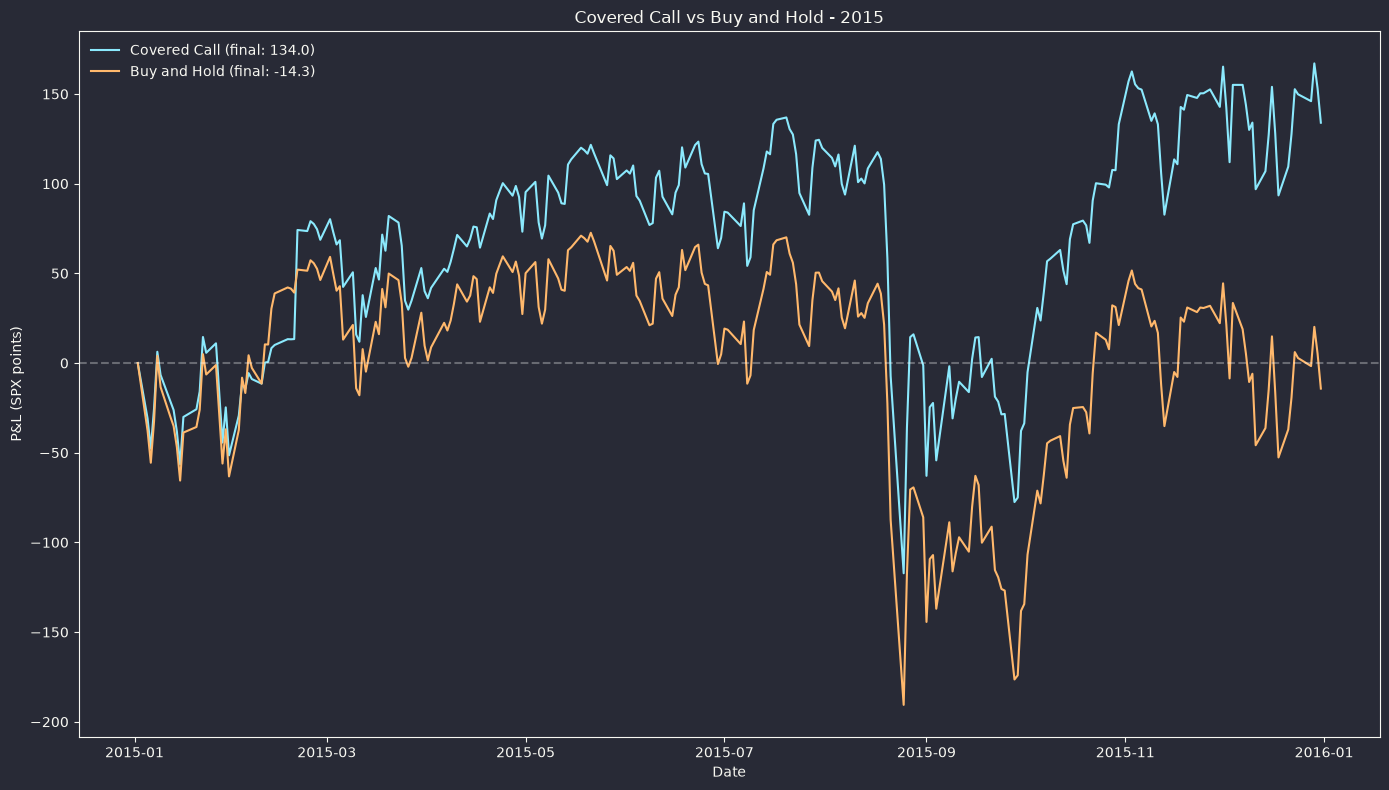

In [105]:
plt.figure(figsize=(14, 8))
plt.plot(full_results['date'], full_results['total_cumulative_pnl'], label=f'Covered Call (final: {cc_final:.1f})')
plt.plot(full_results['date'], full_results['buy_and_hold'], label=f'Buy and Hold (final: {bh_final:.1f})')
plt.axhline(y=0, color='white', linestyle='--', alpha=0.3)
plt.title('Covered Call vs Buy and Hold - 2015')
plt.xlabel('Date')
plt.ylabel('P&L (SPX points)')
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
daily_returns = full_results['combined_daily_pnl'] / full_results['spot'].iloc[0]
sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
print(f"Covered Call Sharpe Ratio: {sharpe:.2f}")

Covered Call Sharpe Ratio: 0.43


In [107]:
bh_daily_returns = full_results['spx_return']
bh_sharpe = (bh_daily_returns.mean() / bh_daily_returns.std()) * np.sqrt(252)
print(f'Buy and Hold Sharpe Ratio: {bh_sharpe:.2f}')

Buy and Hold Sharpe Ratio: -0.03


In [108]:
cumulative = full_results['total_cumulative_pnl']
rolling_peak = cumulative.cummax()
drawdown = cumulative - rolling_peak
max_drawdown = drawdown.min()

print(f"Covered Call Max Drawdown: {max_drawdown:.1f} points")

Covered Call Max Drawdown: -254.1 points


In [109]:
bh_cumulative = full_results['buy_and_hold']
bh_rolling_peak = bh_cumulative.cummax()
bh_drawdown = bh_cumulative - bh_rolling_peak
bh_max_drawdown = bh_drawdown.min()

print(f"Buy and Hold Max Drawdown: {bh_max_drawdown:.1f} points")

Buy and Hold Max Drawdown: -263.2 points


In [110]:
start_spot = full_results['spot'].iloc[0]
print(f'Covered Call Max Drawdown: {max_drawdown/start_spot*100:.1f}%')
print(f'Buy and Hold Max Drawdown: {bh_max_drawdown/start_spot*100:.1f}%')

Covered Call Max Drawdown: -12.3%
Buy and Hold Max Drawdown: -12.8%


In [112]:
wins = 0
for i, trade in enumerate(all_trades):
    final_spot = trade['spot'].iloc[-1]
    strike = chosen_options[i]['strike_price'].values[0]
    if final_spot < strike:
        wins += 1

In [113]:
win_rate = wins / len(all_trades) * 100
print(f'Win Rate: {win_rate:.1f}% ({wins}/{len(all_trades)} trades)')

Win Rate: 76.9% (10/13 trades)


In [114]:
print(f'Period: 2015-01-02 to 2016-01-02')
print(f'Number of trades: {len(all_trades)}')
print(f'Covered Call Final P&L: {cc_final:.1f} points')
print(f'Buy and Hold Final P&L: {bh_final:.1f} points')
print(f'Covered Call Sharpe: {sharpe:.2f}')
print(f'Buy and Hold Sharpe: {bh_sharpe:.2f}')
print(f'Covered Call Max Drawdown: {max_drawdown/start_spot*100:.1f}%')
print(f'Buy and Hold Max Drawdown: {bh_max_drawdown/start_spot*100:.1f}%')
print(f'Win Rate: {win_rate:.1f}%')

Period: 2015-01-02 to 2016-01-02
Number of trades: 13
Covered Call Final P&L: 134.0 points
Buy and Hold Final P&L: -14.3 points
Covered Call Sharpe: 0.43
Buy and Hold Sharpe: -0.03
Covered Call Max Drawdown: -12.3%
Buy and Hold Max Drawdown: -12.8%
Win Rate: 76.9%
